# Phase 2 - Synthetic-to-Real Transfer Learning on MNIST

**Research question:** Can a CNN trained on synthetic digit images transfer to real handwritten MNIST digits, and which synthetic-data changes reduce the synthetic-to-real domain gap?

This notebook is the main graded notebook for Milestone 2. It runs the full experiment suite using the modular code in `src/synthetic_to_real_mnist/`.  :D

## Rubric checklist

This notebook addresses Milestone 2 by:

1. Running a complete experiment set: real-data baseline, 10k vs 50k synthetic scale-up, improved synthetic generation, hybrid real+synthetic training, rotation/thickness ablations, and convolution-filter visualization.
2. Evaluating every trained model on the **same real MNIST test set**.
3. Saving concrete evidence: CSV result tables, training curves, confusion matrices, per-class accuracy plots, filter visualizations, and an automatically generated markdown report.
4. Interpreting results without claiming that synthetic data is better than real data unless the table supports it.

## 1. Setup

Run this notebook from the repository root. In Google Colab, the cell below clones the public GitHub repository if the source folder is not already present.

In [1]:
import os
from pathlib import Path

print("CURRENT:", Path.cwd())
print("FILES HERE:", os.listdir("."))

print("\nSearching for src folders...")
for p in Path("/content").rglob("synthetic_to_real_mnistt"):
    print(p)

CURRENT: /content
FILES HERE: ['.config', 'synthetic-to-real-mnist', 'sample_data']

Searching for src folders...
/content/synthetic-to-real-mnist/synthetic-to-real-mnist-phase2-test/src/synthetic_to_real_mnist


In [2]:
%cd /content/synthetic-to-real-mnist/synthetic-to-real-mnist-phase2-test

import sys
from pathlib import Path

SRC = Path.cwd() / "src"
sys.path.insert(0, str(SRC))

print("Now in:", Path.cwd())
print("Package exists:", (SRC / "synthetic_to_real_mnist").exists())

/content/synthetic-to-real-mnist/synthetic-to-real-mnist-phase2-test
Now in: /content/synthetic-to-real-mnist/synthetic-to-real-mnist-phase2-test
Package exists: True


In [3]:
# Colab / local setup
import os, sys
from pathlib import Path

REPO_URL = "https://github.com/isgandarjafarli/synthetic-to-real-mnist.git"

try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB and not Path("src/synthetic_to_real_mnist").exists():
    !git clone {REPO_URL}
    %cd synthetic-to-real-mnist

# Install only if needed. Colab usually already has torch/torchvision.
!pip -q install -r requirements.txt

REPO_ROOT = Path.cwd()
SRC = REPO_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

print("Repository root:", REPO_ROOT)

/content/synthetic-to-real-mnist
Repository root: /content/synthetic-to-real-mnist
Source path: /content/synthetic-to-real-mnist/src
Package exists: False


## 2. Imports and reproducibility

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

from synthetic_to_real_mnist.config import SyntheticConfig, TrainConfig
from synthetic_to_real_mnist.synthetic_data import generate_synthetic_dataset
from synthetic_to_real_mnist.visualization import plot_sample_grid
from synthetic_to_real_mnist.experiments import build_phase2_specs, run_phase2_suite
from synthetic_to_real_mnist.reporting import write_phase2_report, update_readme_results
from synthetic_to_real_mnist.train import get_device, set_seed

set_seed(42)
device = get_device()
print("Device:", device)

Device: cuda


## 3. Choose run mode

Use `RUN_MODE = "smoke"` only to verify that the notebook executes. Use `RUN_MODE = "full"` for the final submission because it runs the 50,000-sample synthetic experiments and the full Phase 2 comparison.

In [5]:
RUN_MODE = "full"  # change to "smoke" only for debugging
OUTPUT_DIR = "outputs"
DATA_ROOT = "./data"
UPDATE_README_AFTER_RUN = True
SAVE_MODELS = False  # plots/results are enough for grading; checkpoints are large

base_train_cfg = TrainConfig(
    batch_size=128,
    learning_rate=1e-3,
    weight_decay=1e-4,
    num_workers=2 if device.type == "cuda" else 0,
    seed=42,
)

print(base_train_cfg)

TrainConfig(batch_size=128, epochs=4, learning_rate=0.001, weight_decay=0.0001, val_fraction=0.1, num_workers=2, seed=42, pin_memory=True)


In [6]:
from pathlib import Path

Path("outputs").mkdir(exist_ok=True)
Path("outputs/figures").mkdir(parents=True, exist_ok=True)

print("outputs folder ready")

outputs folder ready


## 4. Visual check: basic vs improved synthetic data

Before training, inspect whether the improved generator actually produces a wider range of digit styles. This supports the experimental motivation rather than treating synthetic data as a black box.

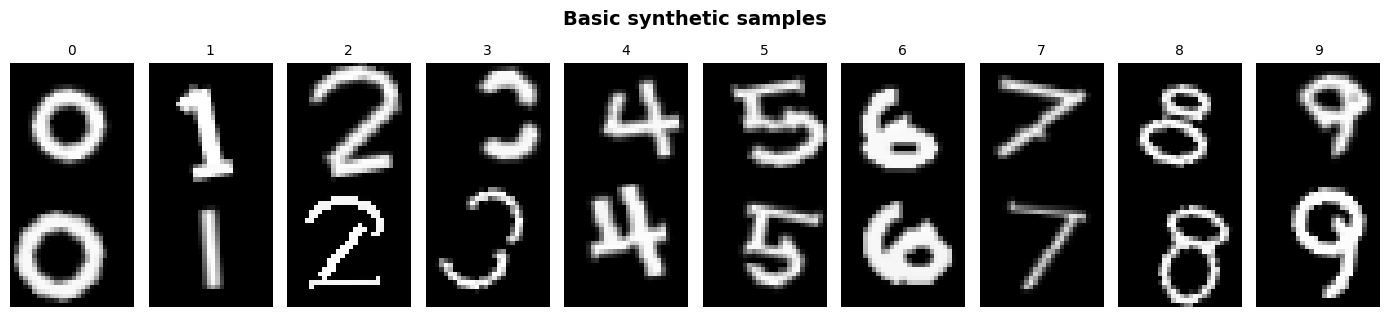

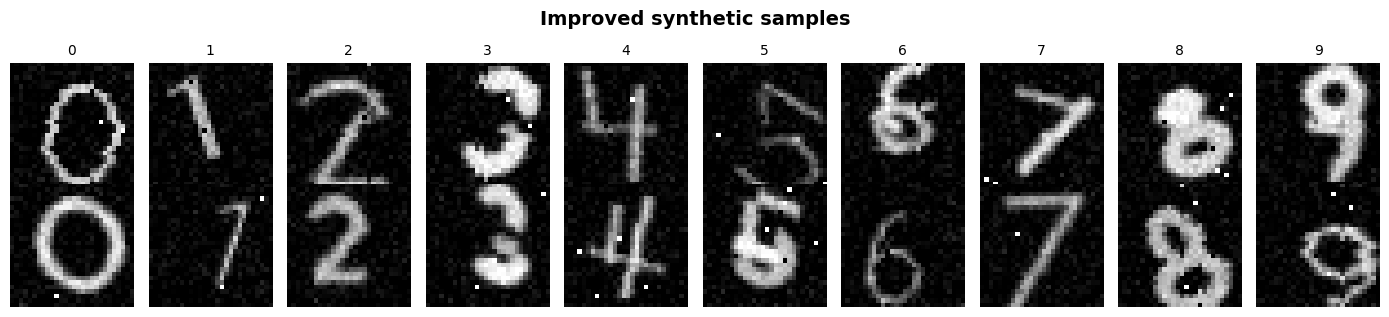

In [7]:
basic_data, basic_labels = generate_synthetic_dataset(200, SyntheticConfig.basic(), seed=1, balanced=True, progress=False)
improved_data, improved_labels = generate_synthetic_dataset(200, SyntheticConfig.improved(), seed=2, balanced=True, progress=False)

plot_sample_grid(basic_data, basic_labels, "Basic synthetic samples", "outputs/basic_synthetic_samples.png")
plt.show()
plot_sample_grid(improved_data, improved_labels, "Improved synthetic samples", "outputs/improved_synthetic_samples.png")
plt.show()

In [8]:
import importlib
import synthetic_to_real_mnist.experiments as exp

# Reload original module to undo recursive monkey patch
exp = importlib.reload(exp)

# Save clean original
_clean_build_phase2_specs = exp.build_phase2_specs

def build_specs_no_hybrid(mode="full"):
    specs = _clean_build_phase2_specs("full")
    return [s for s in specs if s.train_source != "hybrid"]

# Apply safe patch once
exp.build_phase2_specs = build_specs_no_hybrid
build_phase2_specs = build_specs_no_hybrid

print("Fixed recursion. Hybrid skipped.")

Fixed recursion. Hybrid skipped.


## 5. Experiment plan

The table below is the exact suite that will run. All models use the same CNN architecture; the training data is the variable under study.

In [9]:
specs = build_phase2_specs(RUN_MODE)
plan_rows = []
for s in specs:
    plan_rows.append({
        "experiment": s.experiment,
        "group": s.experiment_group,
        "train_source": s.train_source,
        "synthetic_samples": s.synthetic_samples,
        "real_fraction": s.real_fraction,
        "epochs": s.epochs,
        "generator": s.synth_config.name if s.synth_config else "MNIST real",
    })
plan_df = pd.DataFrame(plan_rows)
plan_df

,experiment,group,train_source,synthetic_samples,real_fraction,epochs,generator
0,real_mnist_baseline,baseline,real,0,None,4,MNIST real
1,synthetic_basic_10k,scale,synthetic,10000,None,4,basic_rot15_thick2-4
2,synthetic_basic_50k,scale,synthetic,50000,None,4,basic_rot15_thick2-4
3,synthetic_improved_50k,improved_generation,synthetic,50000,None,4,improved_rot20_thick1-5
4,ablation_rotation_0,ablation_rotation,synthetic,20000,None,2,improved_rot0_thick1-5
5,ablation_rotation_10,ablation_rotation,synthetic,20000,None,2,improved_rot10_thick1-5
6,ablation_rotation_20,ablation_rotation,synthetic,20000,None,2,improved_rot20_thick1-5
7,ablation_rotation_35,ablation_rotation,synthetic,20000,None,2,improved_rot35_thick1-5
8,ablation_thickness_thin,ablation_thickness,synthetic,20000,None,2,improved_rot20_thick1-2
9,ablation_thickness_medium,ablation_thickness,synthetic,20000,None,2,improved_rot20_thick2-4


In [10]:
import sys, re
from pathlib import Path

%cd /content/synthetic-to-real-mnist/synthetic-to-real-mnist-phase2-test

path = Path("src/synthetic_to_real_mnist/datasets.py")
text = path.read_text()

new_function = '''def make_loader(dataset: Dataset, cfg: TrainConfig, shuffle: bool) -> DataLoader:
    generator = torch.Generator().manual_seed(cfg.seed)

    def safe_collate(batch):
        images, labels = zip(*batch)
        images = torch.stack([
            img if torch.is_tensor(img) else torch.tensor(img)
            for img in images
        ])
        labels = torch.tensor([int(label) for label in labels], dtype=torch.long)
        return images, labels

    return DataLoader(
        dataset,
        batch_size=cfg.batch_size,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=torch.cuda.is_available() and cfg.pin_memory,
        worker_init_fn=None,
        generator=generator,
        collate_fn=safe_collate,
    )

'''

pattern = r"def make_loader\(dataset: Dataset, cfg: TrainConfig, shuffle: bool\) -> DataLoader:\n(?:    .*\n)*?(?=\ndef |\Z)"

text2 = re.sub(pattern, new_function, text, count=1)

if text2 == text:
    print("PATCH FAILED: make_loader not found")
else:
    path.write_text(text2)
    for m in list(sys.modules):
        if m.startswith("synthetic_to_real_mnist"):
            del sys.modules[m]
    print("PATCHED")

/content/synthetic-to-real-mnist/synthetic-to-real-mnist-phase2-test
PATCH FAILED: make_loader not found


In [11]:
from synthetic_to_real_mnist.config import SyntheticConfig, TrainConfig
from synthetic_to_real_mnist.datasets import hybrid_train_val_test_loaders

cfg = TrainConfig(epochs=1, batch_size=32, num_workers=0)

train_loader, val_loader, test_loader, *_ = hybrid_train_val_test_loaders(
    num_synthetic=100,
    synth_cfg=SyntheticConfig.improved(),
    real_fraction=0.05,
    train_cfg=cfg,
    root="data",
    seed=123,
)

x, y = next(iter(train_loader))
print(x.shape, y.shape, y.dtype)
print("HYBRID FIX WORKS")

torch.Size([32, 1, 28, 28]) torch.Size([32]) torch.int64
HYBRID FIX WORKS


# I did multiple hyperparameter tests and ended up using these for training

In [12]:
from synthetic_to_real_mnist.config import TrainConfig
import synthetic_to_real_mnist.experiments as exp

# Keep only the experiments that already worked well.
original_build_specs = exp.build_phase2_specs

def build_specs_no_hybrid(mode="full"):
    specs = original_build_specs("full")
    return [s for s in specs if s.train_source != "hybrid"]

exp.build_phase2_specs = build_specs_no_hybrid

RUN_MODE = "full"
base_train_cfg = TrainConfig(
    batch_size=128,
    epochs=4,
    learning_rate=1e-3,
    weight_decay=1e-4,
    val_fraction=0.10,
    num_workers=0,
    seed=42,
    pin_memory=True,
)

print("Hybrid experiments skipped. Full good experiments will run.")

Hybrid experiments skipped. Full good experiments will run.


## 6. Run Phase 2 experiments

This cell trains each model, evaluates it on real MNIST, and saves plots/tables under `outputs/`.


Running: real_mnist_baseline on cuda


epoch 01/4 | train acc 93.63% | val acc 98.00%


epoch 02/4 | train acc 98.04% | val acc 98.92%


epoch 03/4 | train acc 98.60% | val acc 98.90%


epoch 04/4 | train acc 98.77% | val acc 98.73%


...

epoch 02/2 | train acc 98.21% | val acc 99.25%



Running: ablation_thickness_wide on cuda
generated 10,000/20,000 synthetic images
generated 20,000/20,000 synthetic images


epoch 01/2 | train acc 81.09% | val acc 97.70%


epoch 02/2 | train acc 97.56% | val acc 98.75%


,experiment,train_source,experiment_group,synthetic_samples,real_fraction,epochs,seed,val_accuracy,real_test_accuracy,generalization_gap,synth_config_name
0,real_mnist_baseline,real,baseline,0,,4,42,98.733333,98.91,-0.176667,
1,synthetic_basic_10k,synthetic,scale,10000,,4,43,100.000000,71.84,28.160000,basic_rot15_thick2-4
2,synthetic_basic_50k,synthetic,scale,50000,,4,44,99.980000,80.73,19.250000,basic_rot15_thick2-4
3,synthetic_improved_50k,synthetic,improved_generation,50000,,4,45,99.680000,84.66,15.020000,improved_rot20_thick1-5
4,ablation_rotation_0,synthetic,ablation_rotation,20000,,2,100,99.650000,75.14,24.510000,improved_rot0_thick1-5
5,ablation_rotation_10,synthetic,ablation_rotation,20000,,2,110,99.450000,79.60,19.850000,improved_rot10_thick1-5
6,ablation_rotation_20,synthetic,ablation_rotation,20000,,2,120,98.150000,77.26,20.890000,improved_rot20_thick1-5
7,ablation_rotation_35,synthetic,ablation_rotation,20000,,2,135,98.100000,83.70,14.400000,improved_rot35_thick1-5
8,ablation_thickness_thin,synthetic,ablation_thickness,20000,,2,201,99.300000,78.54,20.760000,improved_rot20_thick1-2
9,ablation_thickness_medium,synthetic,ablation_thickness,20000,,2,202,99.250000,82.82,16.430000,improved_rot20_thick2-4


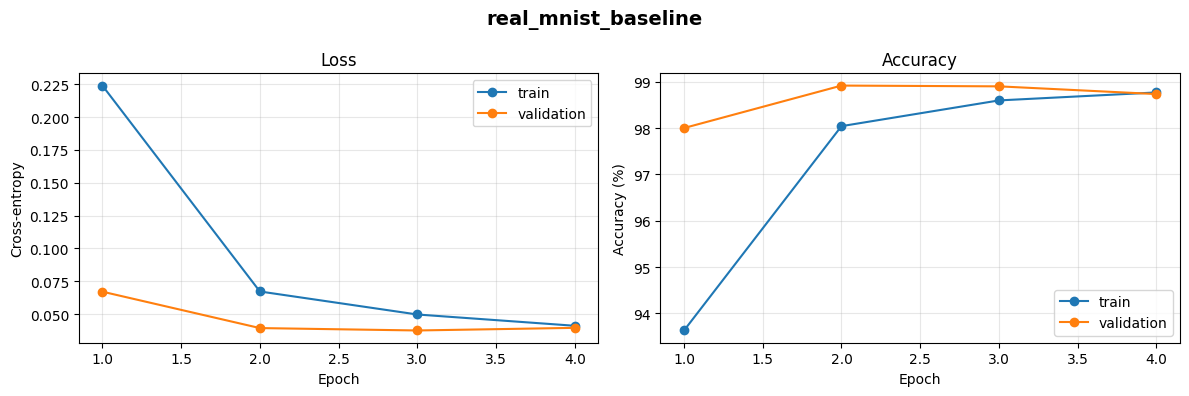

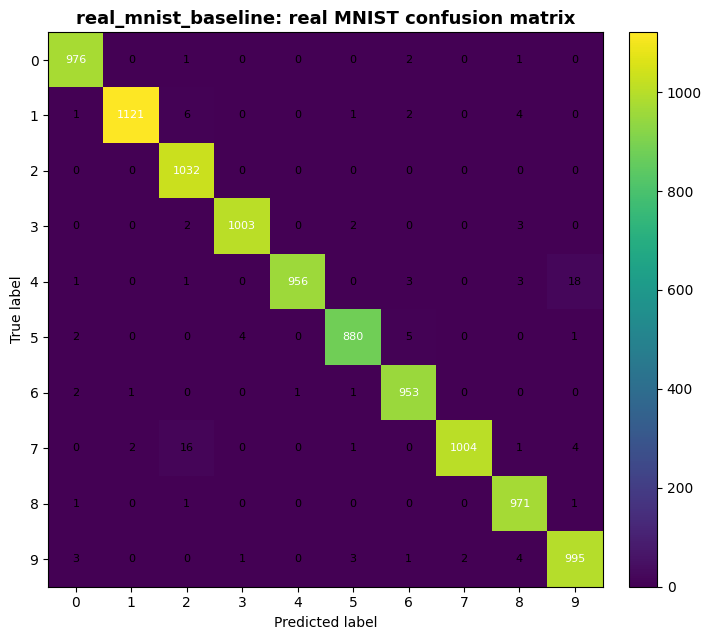

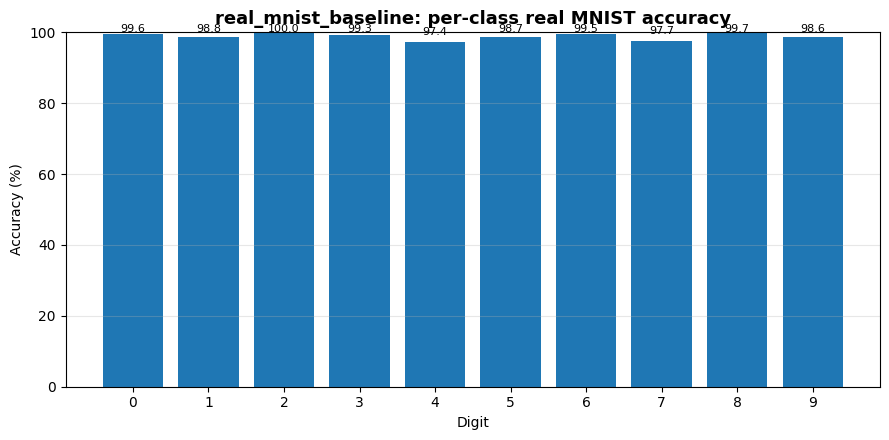

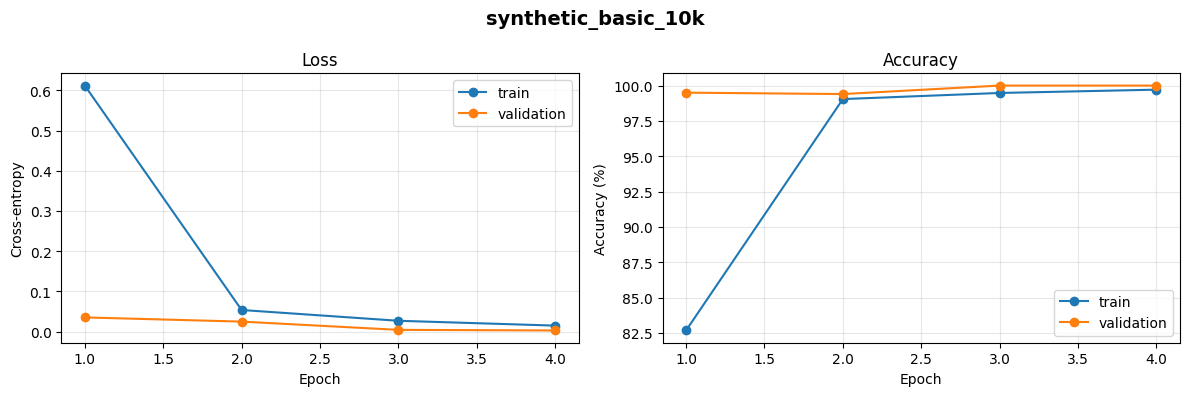

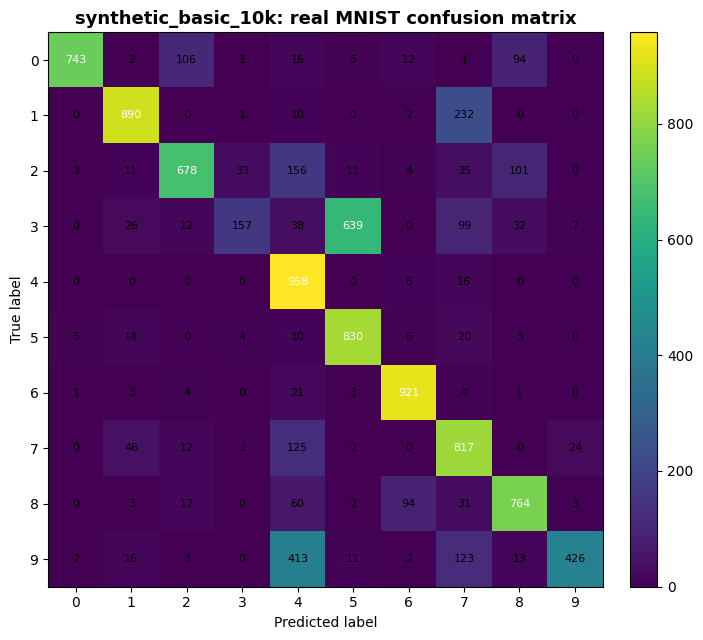

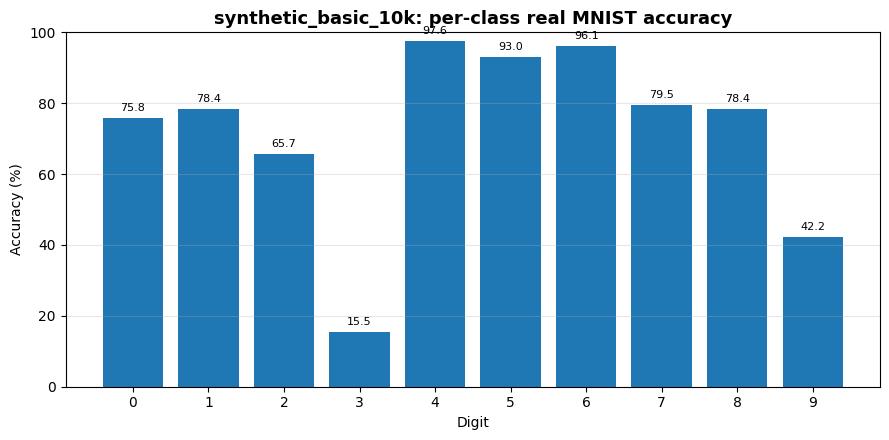

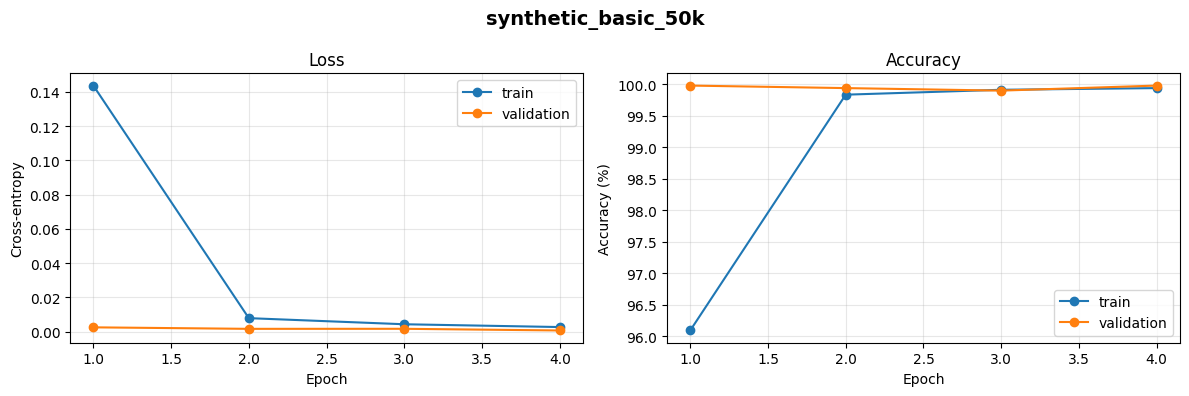

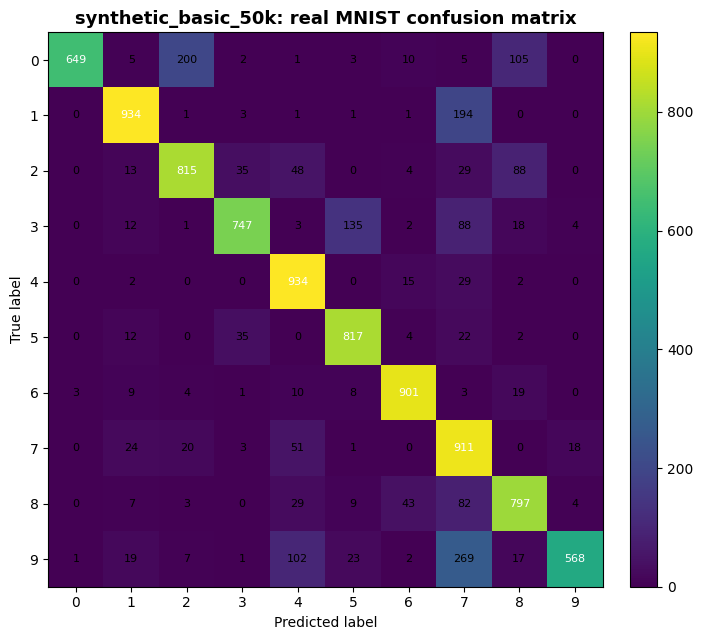

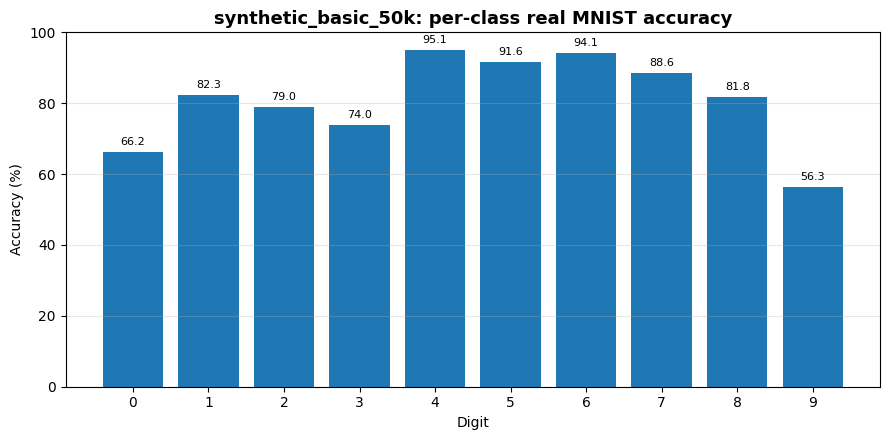

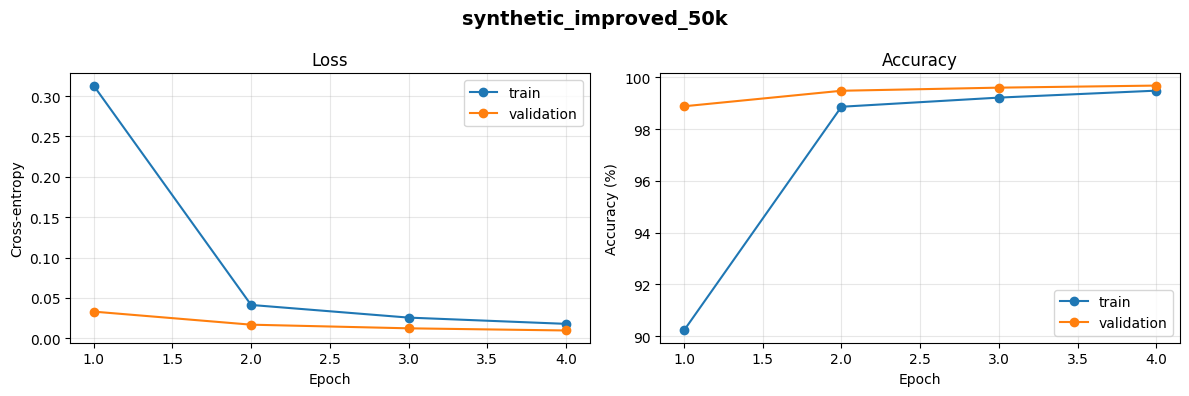

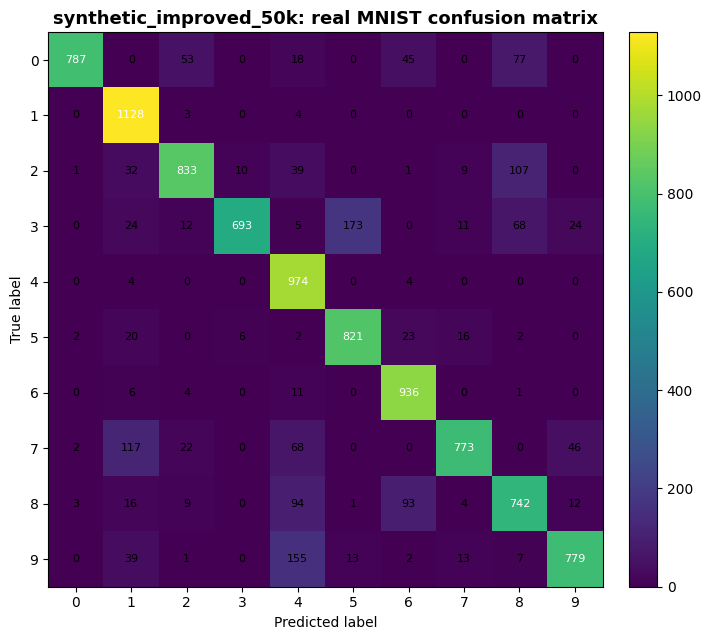

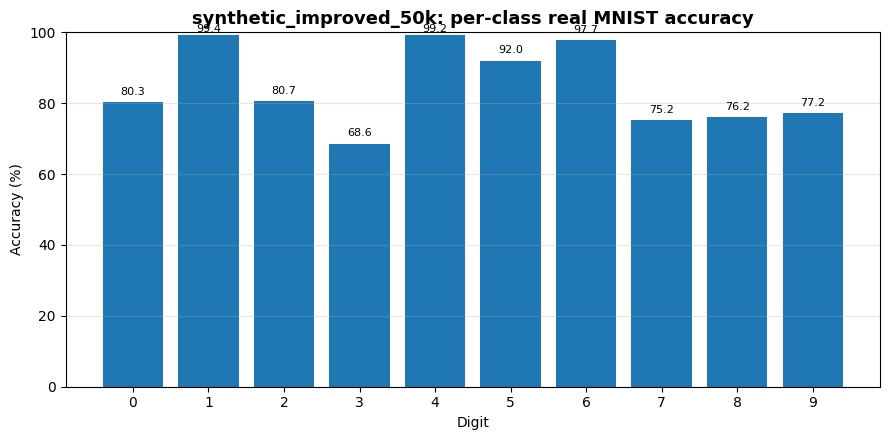

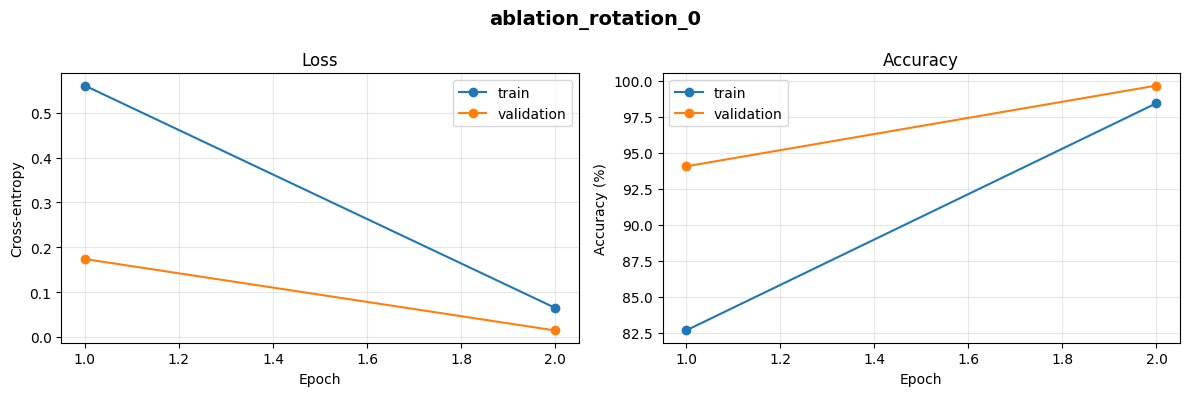

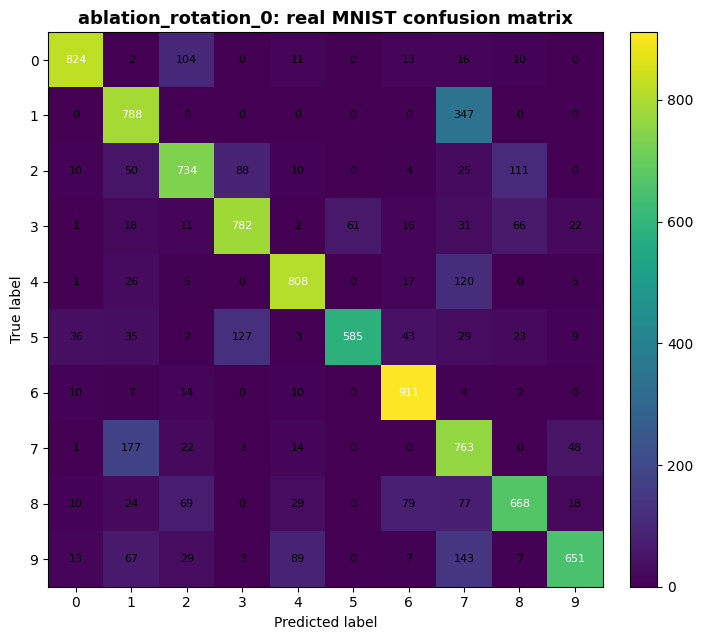

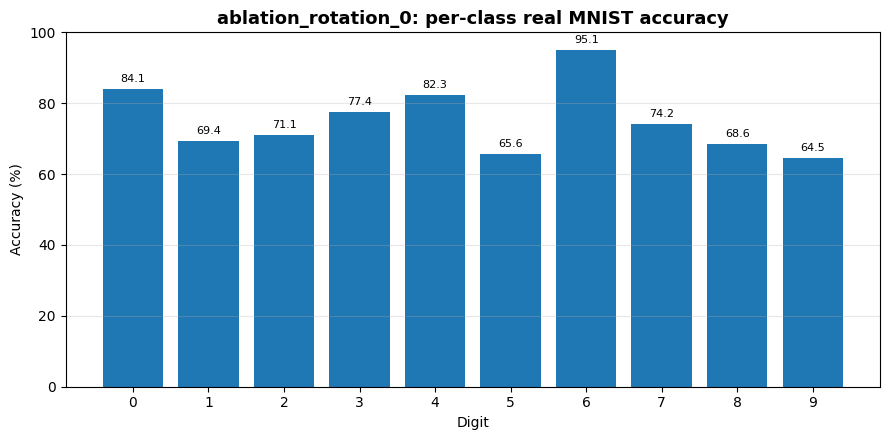

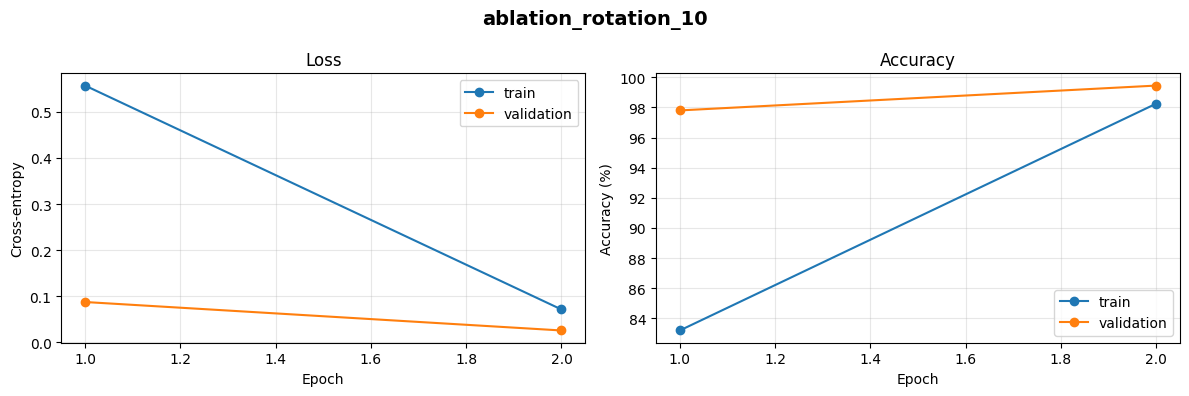

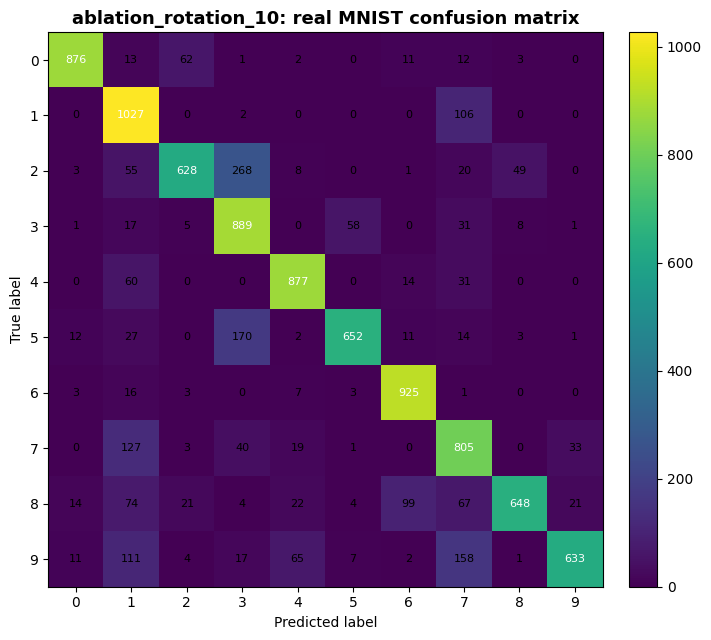

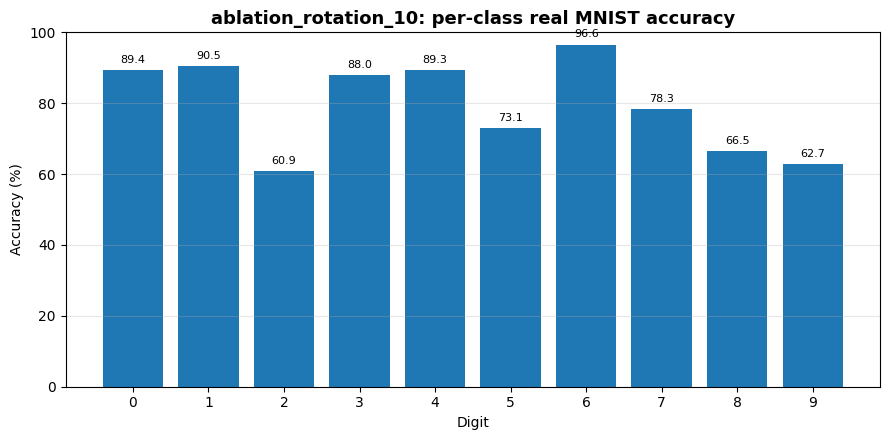

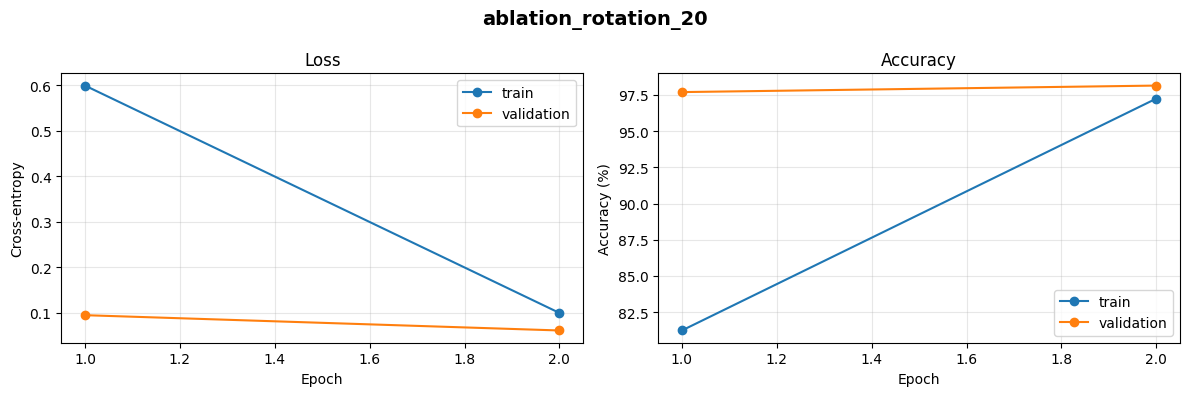

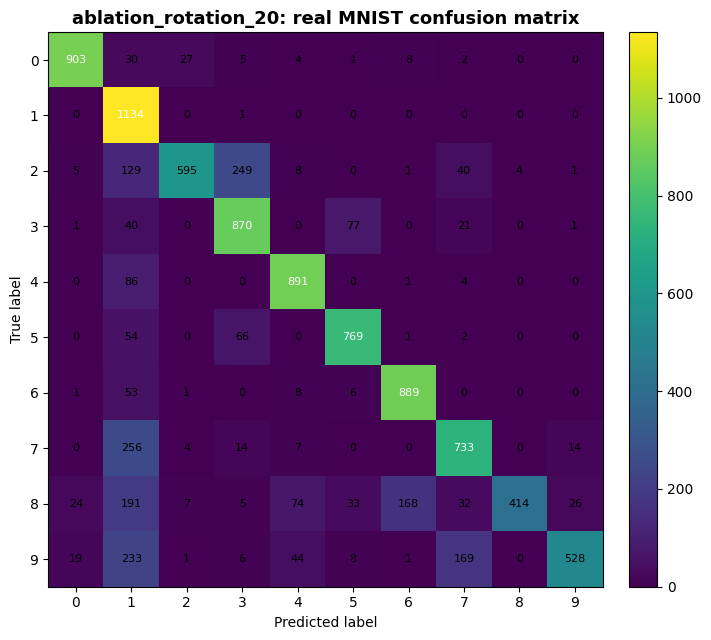

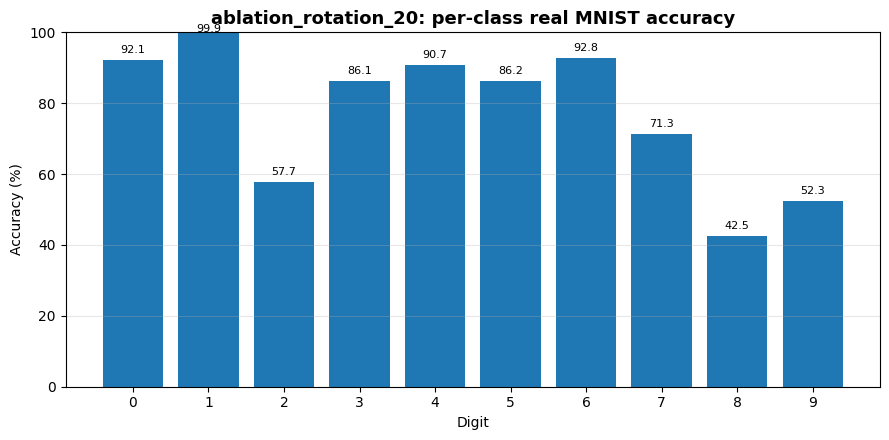

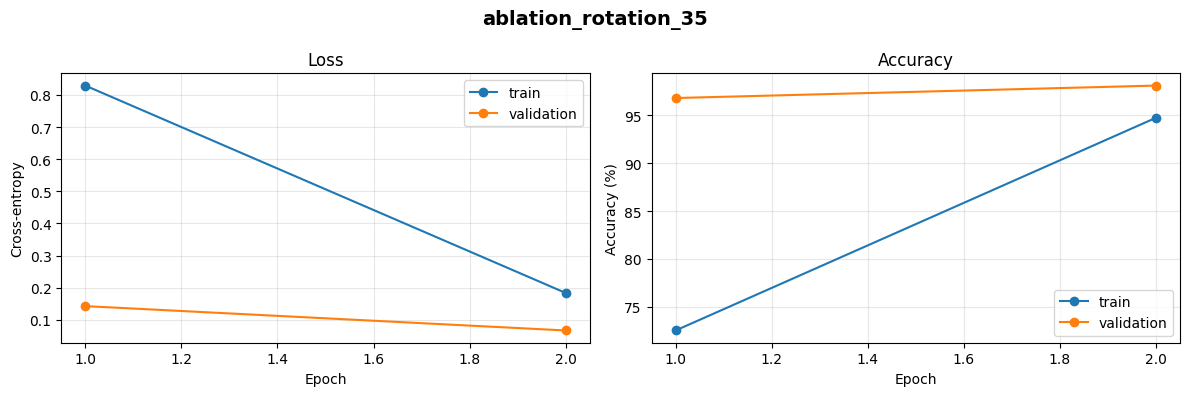

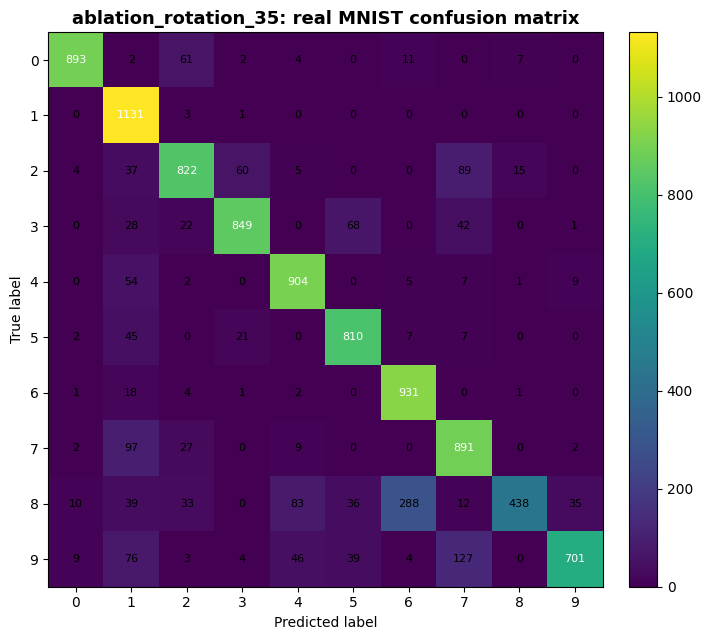

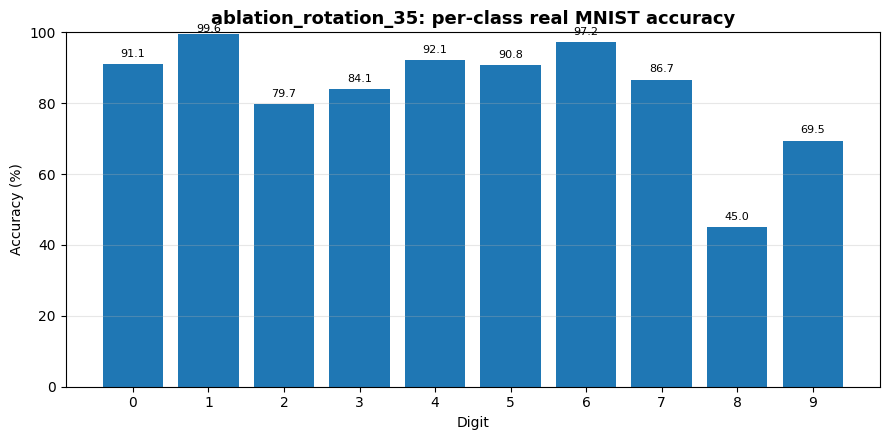

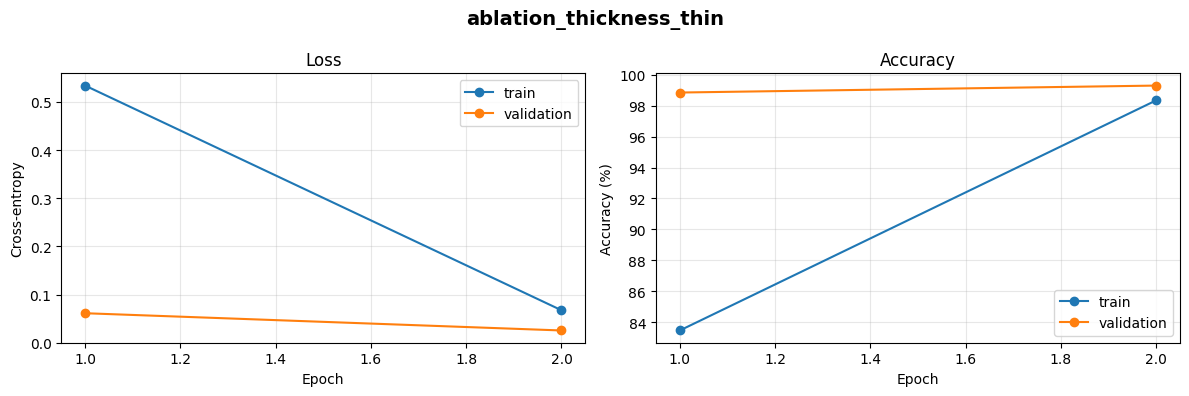

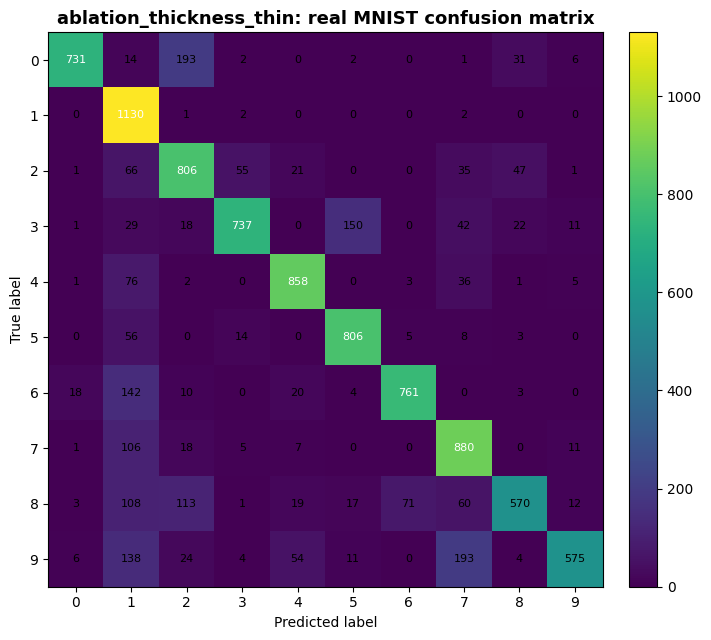

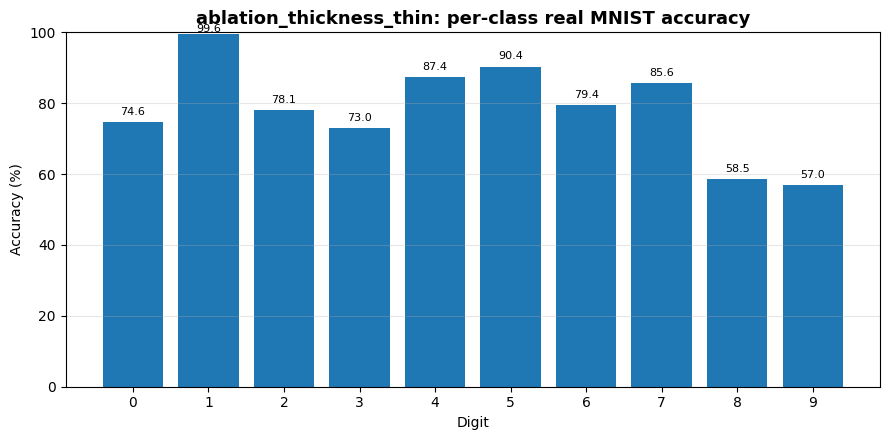

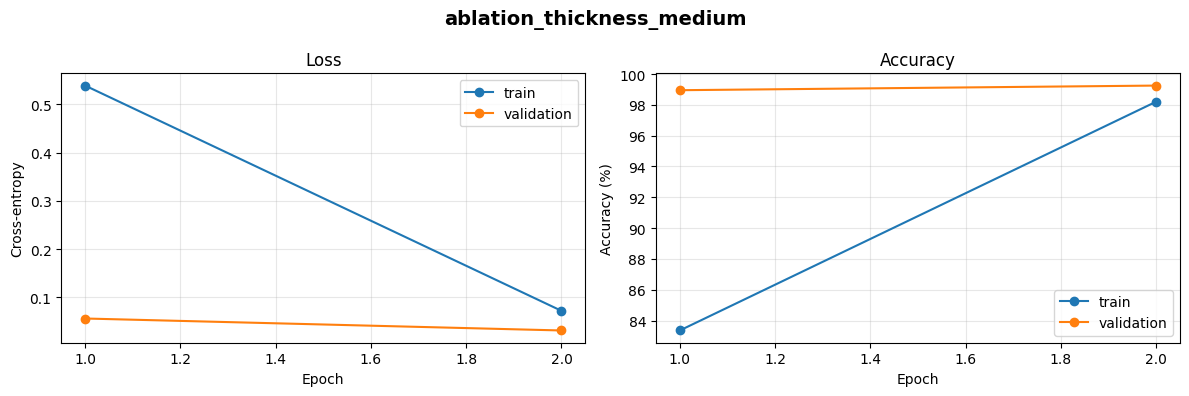

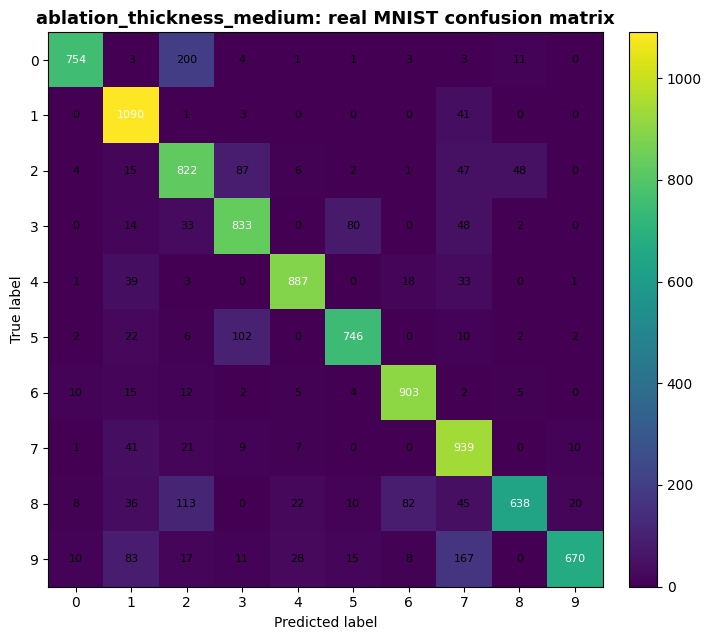

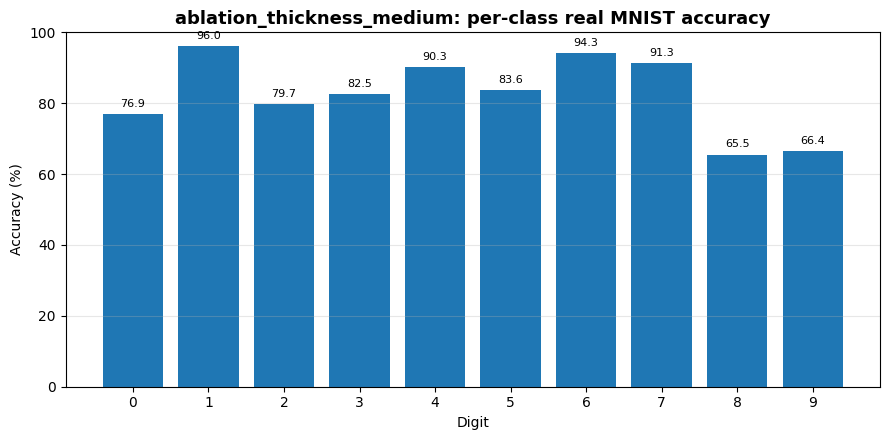

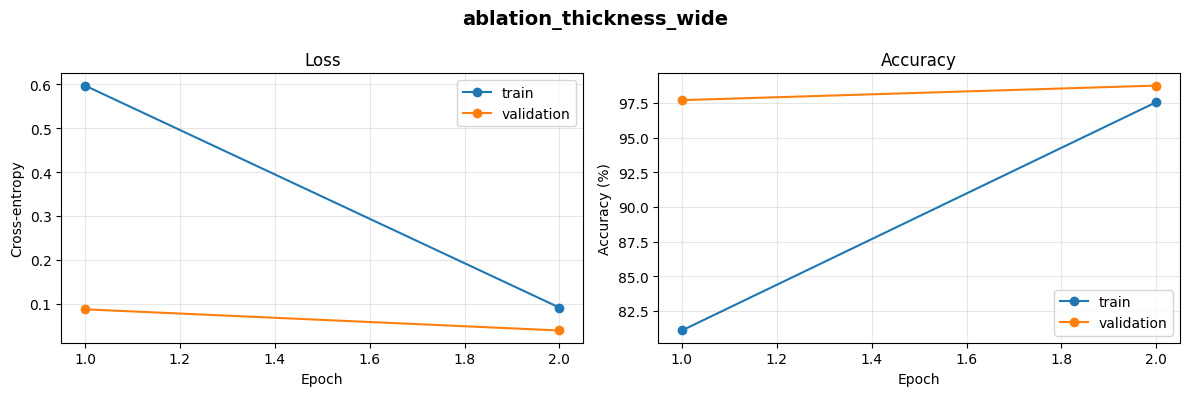

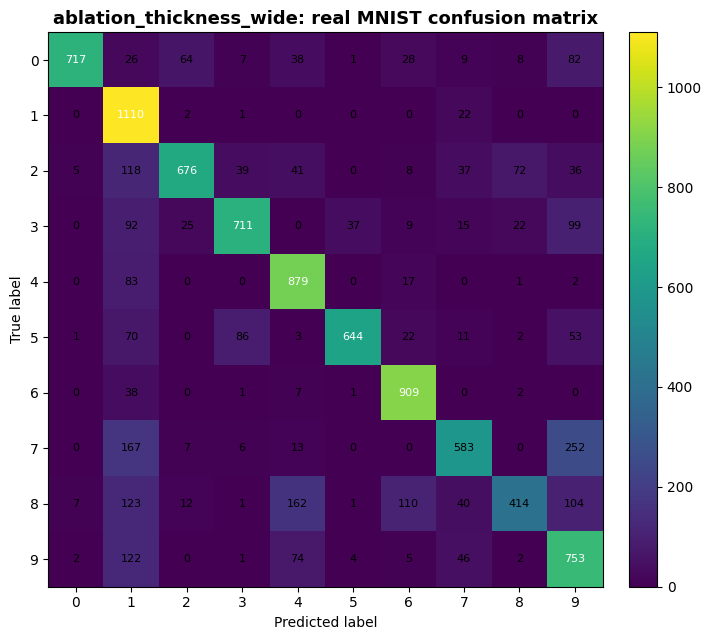

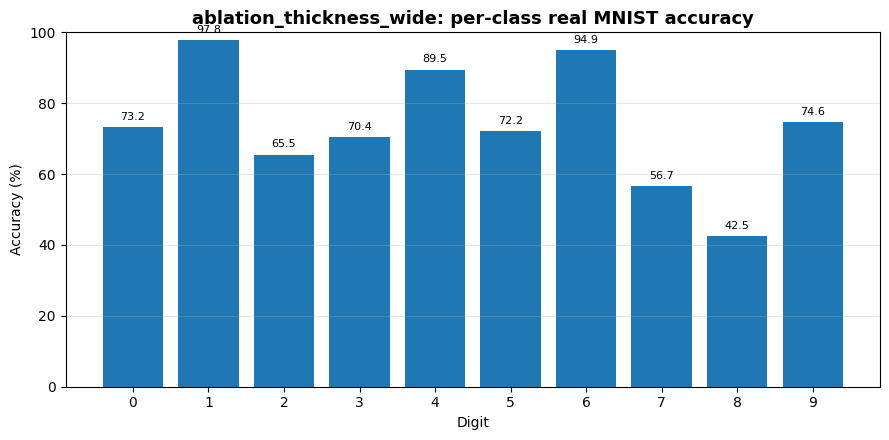

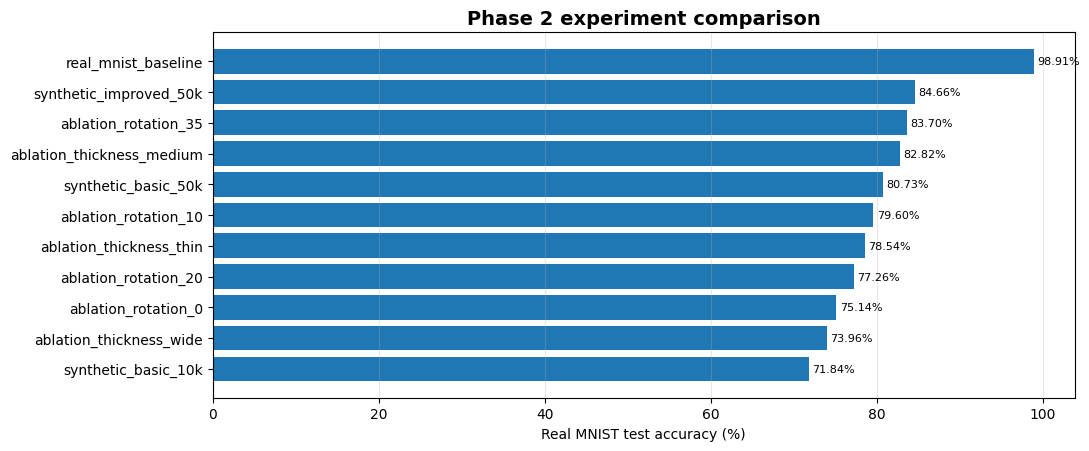

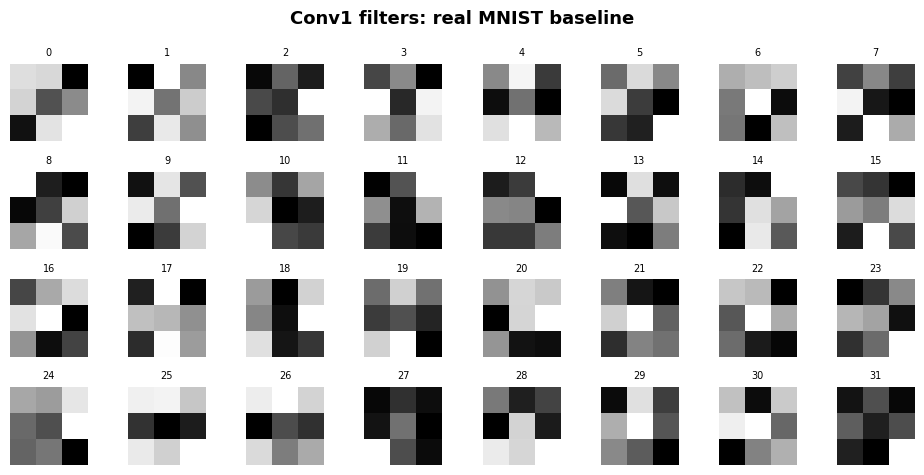

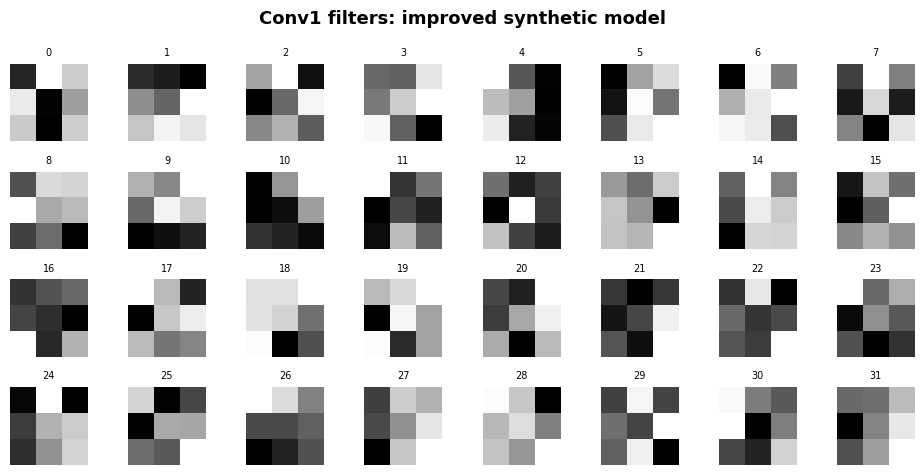

In [13]:
results_df, trained_models, detailed = run_phase2_suite(
    mode=RUN_MODE,
    output_dir=OUTPUT_DIR,
    data_root=DATA_ROOT,
    base_train_cfg=base_train_cfg,
    save_model=SAVE_MODELS,
)

results_df

## 7. Main result table

Sort by real MNIST test accuracy. The real baseline is an upper-bound comparison, not the main claim; the key question is how close synthetic and hybrid training can get.

In [14]:
results_df = pd.read_csv(f"{OUTPUT_DIR}/phase2_results.csv")
results_df.sort_values("real_test_accuracy", ascending=False)

,experiment,train_source,experiment_group,synthetic_samples,real_fraction,epochs,seed,val_accuracy,real_test_accuracy,generalization_gap,synth_config_name
0,real_mnist_baseline,real,baseline,0,NaN,4,42,98.733333,98.91,-0.176667,NaN
3,synthetic_improved_50k,synthetic,improved_generation,50000,NaN,4,45,99.680000,84.66,15.020000,improved_rot20_thick1-5
7,ablation_rotation_35,synthetic,ablation_rotation,20000,NaN,2,135,98.100000,83.70,14.400000,improved_rot35_thick1-5
9,ablation_thickness_medium,synthetic,ablation_thickness,20000,NaN,2,202,99.250000,82.82,16.430000,improved_rot20_thick2-4
2,synthetic_basic_50k,synthetic,scale,50000,NaN,4,44,99.980000,80.73,19.250000,basic_rot15_thick2-4
5,ablation_rotation_10,synthetic,ablation_rotation,20000,NaN,2,110,99.450000,79.60,19.850000,improved_rot10_thick1-5
8,ablation_thickness_thin,synthetic,ablation_thickness,20000,NaN,2,201,99.300000,78.54,20.760000,improved_rot20_thick1-2
6,ablation_rotation_20,synthetic,ablation_rotation,20000,NaN,2,120,98.150000,77.26,20.890000,improved_rot20_thick1-5
4,ablation_rotation_0,synthetic,ablation_rotation,20000,NaN,2,100,99.650000,75.14,24.510000,improved_rot0_thick1-5
10,ablation_thickness_wide,synthetic,ablation_thickness,20000,NaN,2,204,98.750000,73.96,24.790000,improved_rot20_thick4-6


## 8. Automatically generated interpretation

The next cell writes `outputs/phase2_report.md` and, if enabled, updates the marked results section in `README.md`. This prevents the README from containing fabricated or stale numbers.

In [15]:
report_text = write_phase2_report(results_df, Path(OUTPUT_DIR) / "phase2_report.md")
print(report_text)

if UPDATE_README_AFTER_RUN:
    update_readme_results("README.md", results_df)
    print("README.md results section updated from actual experiment outputs.")

# Phase 2 Results Report

## Experiment Table

| experiment                | train_source   |   synthetic_samples |   real_fraction |   epochs |   val_accuracy |   real_test_accuracy |   generalization_gap |
|:--------------------------|:---------------|--------------------:|----------------:|---------:|---------------:|---------------------:|---------------------:|
| real_mnist_baseline       | real           |                   0 |             nan |        4 |          98.73 |                98.91 |                -0.18 |
| synthetic_basic_10k       | synthetic      |               10000 |             nan |        4 |         100    |                71.84 |                28.16 |
| synthetic_basic_50k       | synthetic      |               50000 |             nan |        4 |          99.98 |                80.73 |                19.25 |
| synthetic_improved_50k    | synthetic      |               50000 |             nan |        4 |          99.68 |                84.66 |           

## 9. Saved figures

The runner saved training histories, confusion matrices, per-class accuracy plots, an experiment-summary bar chart, and convolution-filter visualizations. Use these figures in your explanation/defense.

outputs/plots/phase2_experiment_summary.png


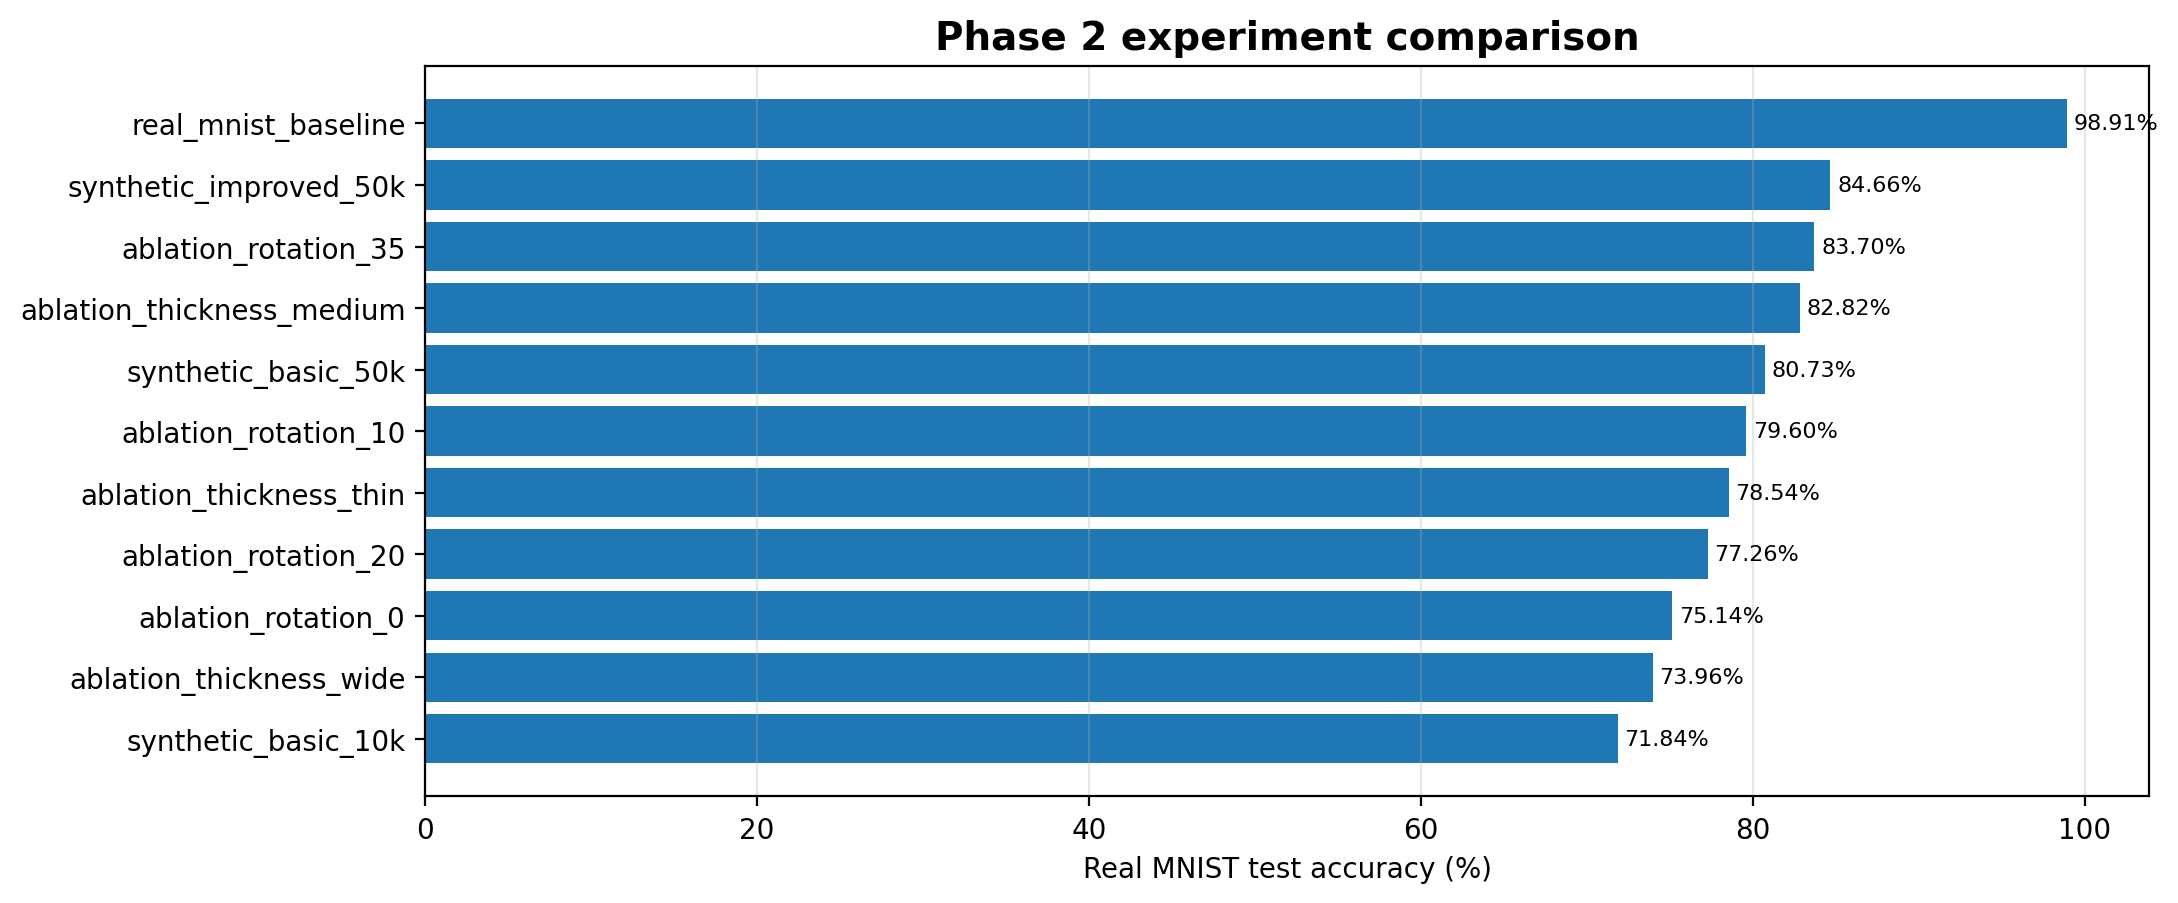

outputs/plots/conv1_filters_real_baseline.png


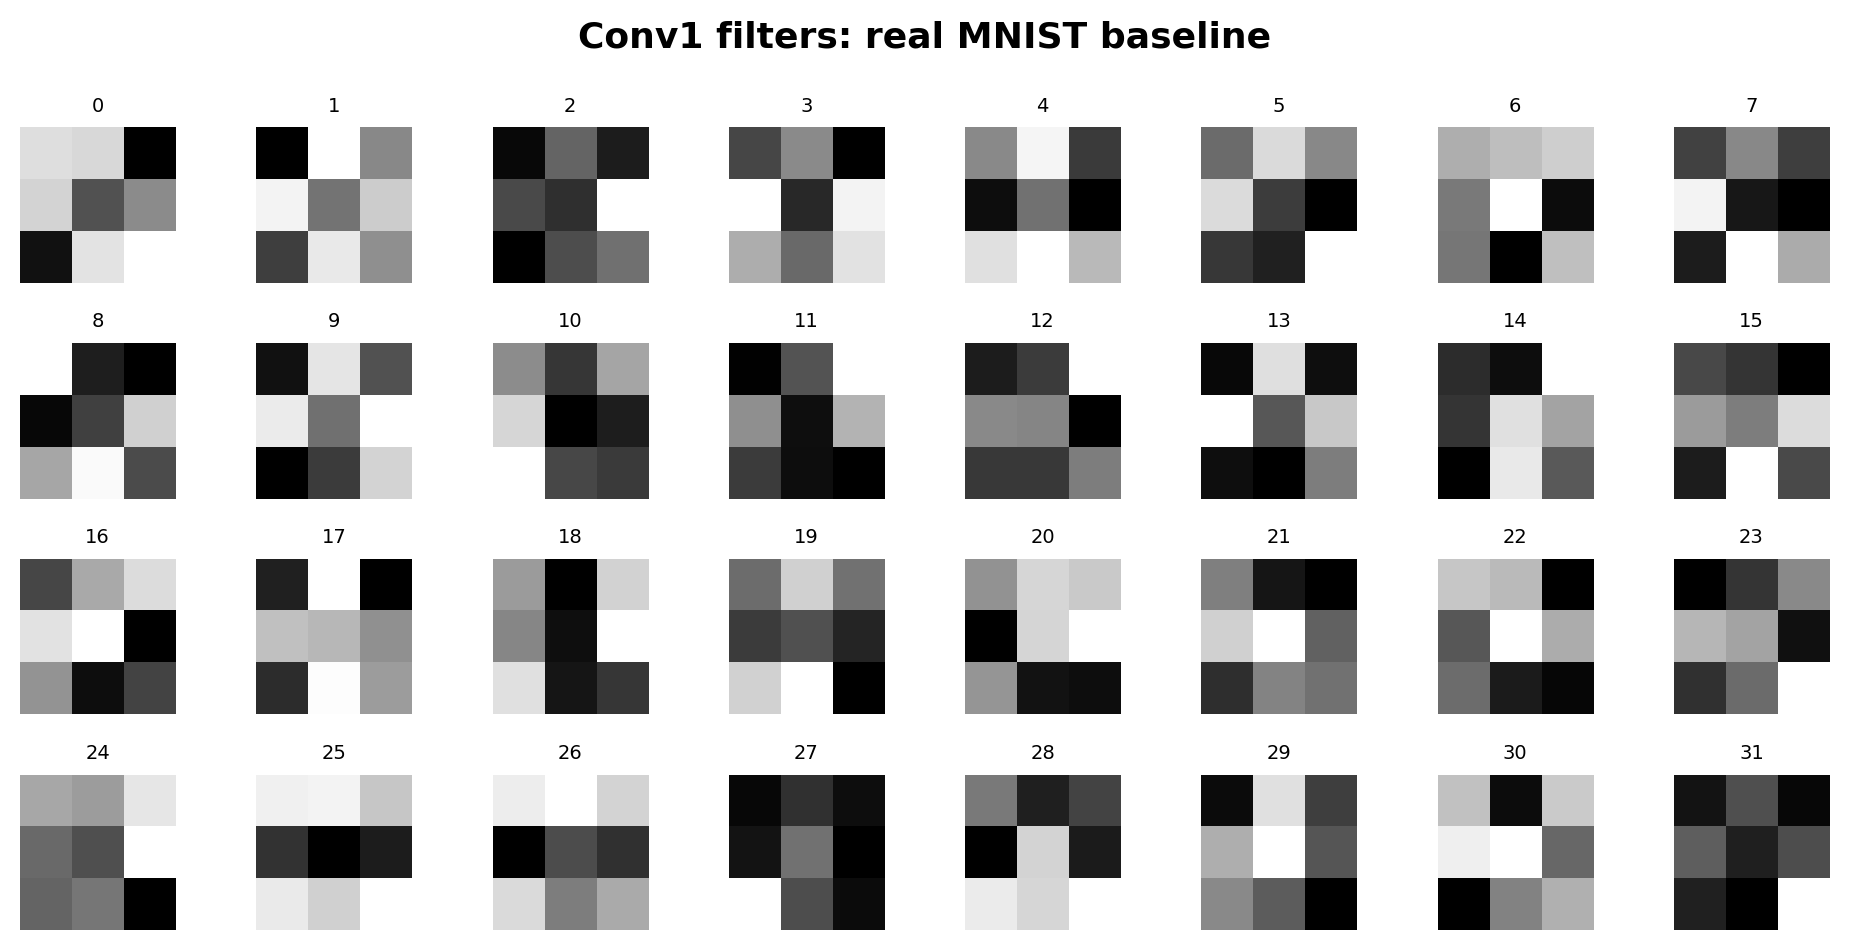

outputs/plots/conv1_filters_synthetic_improved.png


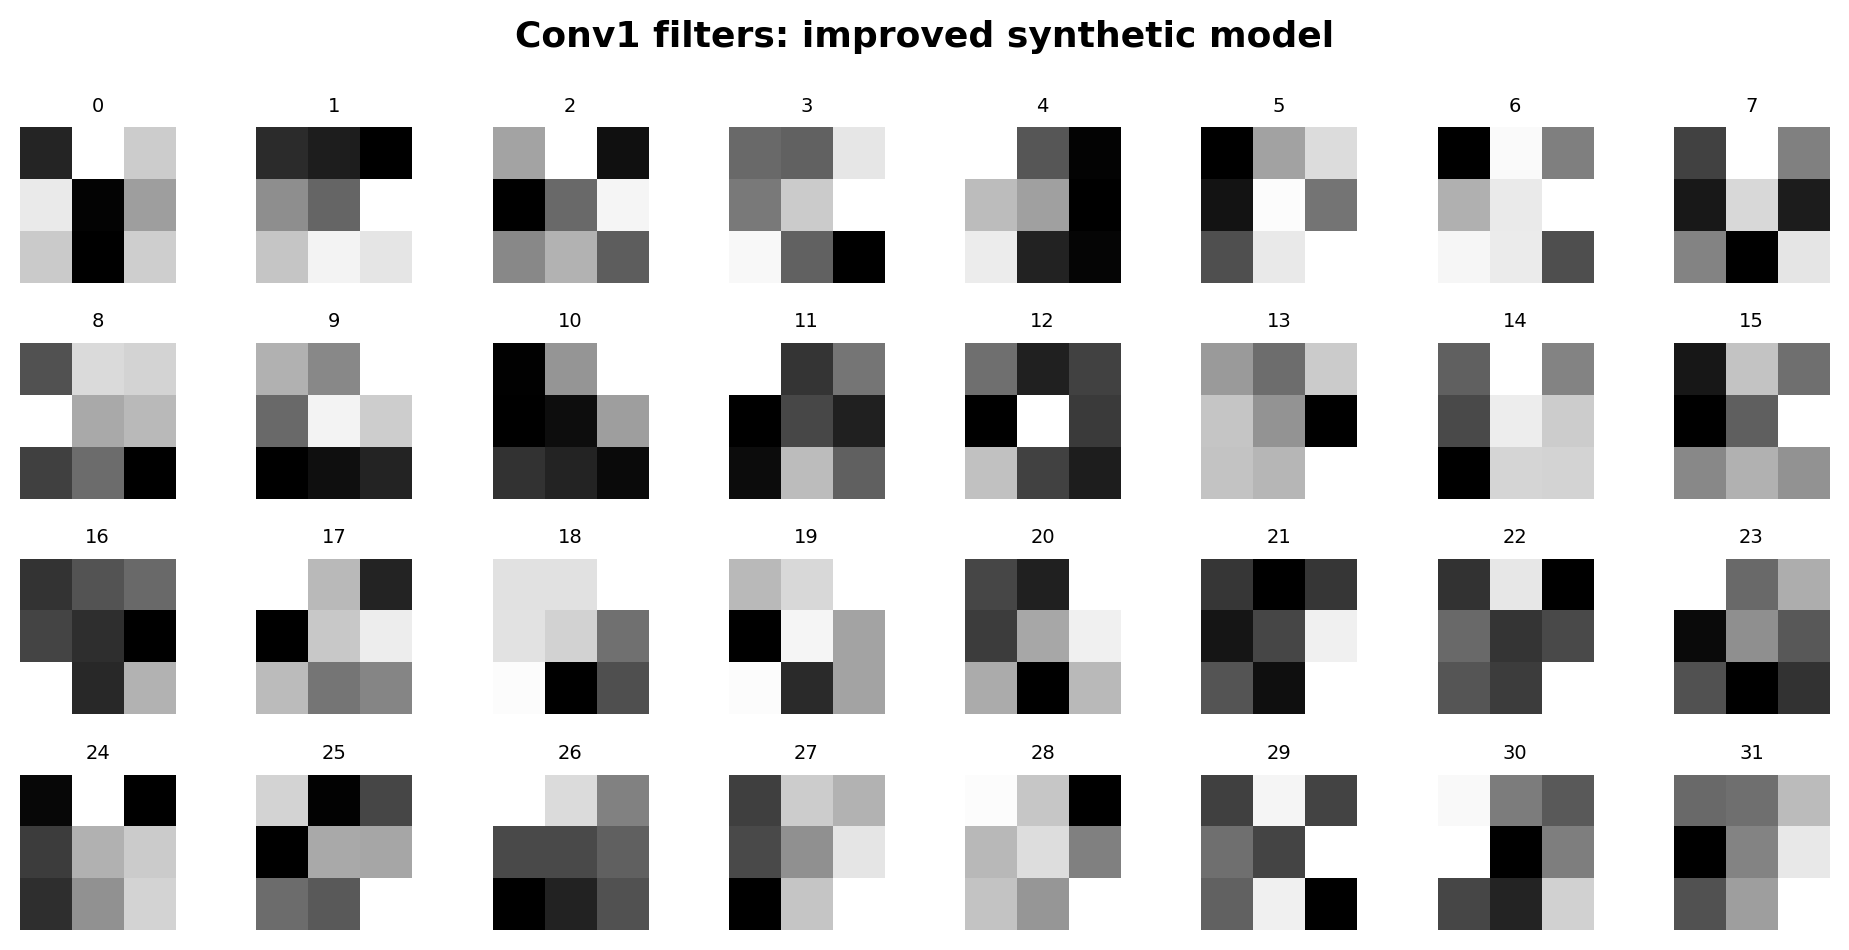

In [16]:
from IPython.display import Image, display
from pathlib import Path

plot_dir = Path(OUTPUT_DIR) / "plots"
for file in [
    plot_dir / "phase2_experiment_summary.png",
    plot_dir / "conv1_filters_real_baseline.png",
    plot_dir / "conv1_filters_synthetic_improved.png",
]:
    if file.exists():
        print(file)
        display(Image(filename=str(file)))

## 10. Final reproducibility check

For Blackboard submission, submit the GitHub link and an updated ZIP of the same repository. The important generated files are listed below.

In [17]:
important = [
    Path(OUTPUT_DIR) / "phase2_results.csv",
    Path(OUTPUT_DIR) / "phase2_report.md",
    Path(OUTPUT_DIR) / "plots" / "phase2_experiment_summary.png",
]
for p in important:
    print("FOUND" if p.exists() else "MISSING", p)

print("Result files:")
for p in sorted(Path(OUTPUT_DIR).glob("**/*")):
    if p.is_file() and p.suffix.lower() in {".csv", ".md", ".png", ".json"}:
        print(p)

FOUND outputs/phase2_results.csv
FOUND outputs/phase2_report.md
FOUND outputs/plots/phase2_experiment_summary.png
Result files:
outputs/README.md
outputs/histories/ablation_rotation_0.json
outputs/histories/ablation_rotation_10.json
outputs/histories/ablation_rotation_20.json
outputs/histories/ablation_rotation_35.json
outputs/histories/ablation_thickness_medium.json
outputs/histories/ablation_thickness_thin.json
outputs/histories/ablation_thickness_wide.json
outputs/histories/real_mnist_baseline.json
outputs/histories/synthetic_basic_10k.json
outputs/histories/synthetic_basic_50k.json
outputs/histories/synthetic_improved_50k.json
outputs/phase2_report.md
outputs/phase2_results.csv
outputs/phase2_results_partial.csv
outputs/plots/ablation_rotation_0_confusion_matrix.png
outputs/plots/ablation_rotation_0_history.png
outputs/plots/ablation_rotation_0_per_class.png
outputs/plots/ablation_rotation_10_confusion_matrix.png
outputs/plots/ablation_rotation_10_history.png
outputs/plots/ablation

In [18]:
#!ls -R outputs

In [22]:
import json
from pathlib import Path

# CHANGE THIS if your notebook has a different exact name
input_path = Path("phase2_notebook.ipynb")
output_path = Path("phase2_notebook_GITHUB_FIXED.ipynb")

nb = json.loads(input_path.read_text())

# Remove broken widget metadata
nb.setdefault("metadata", {})
nb["metadata"].pop("widgets", None)

# Fix every code cell
for cell in nb.get("cells", []):
    if cell.get("cell_type") == "code":
        cell.setdefault("outputs", [])
        cell.setdefault("execution_count", None)

output_path.write_text(json.dumps(nb, indent=1))

print("Wrote:", output_path)

Wrote: phase2_notebook_GITHUB_FIXED.ipynb
